# Preprocesamiento y preparación Spotify

* Objetivo

El objetivo de este notebook es realizar el preprocesamiento de los datos obtenidos durante la etapa de ingeniería de características, dejando los conjuntos de datos preparados para su utilización en modelos de Machine Learning.

En esta etapa se realizan principalmente las siguientes operaciones:

* Carga del dataset spotify_engineering.csv.
* Identificación de variables categóricas.
* Análisis de cardinalidad.
* Visualización de la cantidad de categorías por variable.
* Identificación y definición de variables ordinales.
* Definición de variables categóricas de alta cardinalidad.
* Definición de variables numéricas.
* Codificación mediante BinaryEncoder.
* Codificación ordinal mediante OrdinalEncoder.
* Estandarización mediante StandardScaler.
* Construcción de un ColumnTransformer.
* Separación entre variables predictoras (X) y variable objetivo (y).
* Conversión de popularity_category a valores numéricos.
* División estratificada en conjuntos de entrenamiento y prueba.
* Ajuste del pipeline únicamente sobre el conjunto de entrenamiento.
* Transformación de los conjuntos de entrenamiento y prueba.
* Reconstrucción de los DataFrames preprocesados.
* Exportación de los conjuntos finales.

El resultado de esta etapa corresponde a dos archivos:

* Spotify_train_preprocesado.csv
* Spotify_test_preprocesado.csv

Estos archivos contienen los datos transformados y preparados para el entrenamiento y evaluación de los modelos predictivos.

---

# Importación de librerías


Se importan las librerías necesarias para realizar el análisis y preprocesamiento:

In [ ]:
import pandas as pd
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

from category_encoders import BinaryEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

"""
Al ser utilidades locales del repositorio
se deben realizar la importación luego
del sys.path()
"""

'\nAl ser utilidades locales del repositorio\nse deben realizar la importación luego\ndel sys.path()\n'

---

# Carga del dataset

Se carga el dataset obtenido después de la etapa de ingeniería de características:

In [ ]:
data = pd.read_csv("../dataset/spotify_engineering.csv")

df = data.copy()

df.head()

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre,duration_min,duration_category,popularity_category
0,Gen Hoshino,Comedy,Comedy,73.0,False,0.676,0.4610,1,-6.7460,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic,3.844433,Media,Alta
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,False,0.420,0.1660,1,-17.2350,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic,2.493500,Corta,Media
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,False,0.438,0.3590,0,-9.7340,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic,3.513767,Media,Media
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,False,0.266,0.0596,0,-17.4935,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic,3.365550,Media,Alta
4,Chord Overstreet,Hold On,Hold On,82.0,False,0.618,0.4430,2,-9.6810,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic,3.314217,Media,Muy alta


---

# Identificación de variables categóricas

In [118]:
# Obtener columnas categóricas
columnas_categoricas = df.select_dtypes(
    include=["object", "category", "str"]
).columns

print("Variables categóricas encontradas:")
print(columnas_categoricas)

Variables categóricas encontradas:
Index(['artists', 'album_name', 'track_name', 'track_genre',
       'duration_category', 'popularity_category'],
      dtype='str')


Esta identificación es necesaria porque las variables categóricas no pueden ser utilizadas directamente por la mayoría de los modelos de Machine Learning.

Por esta razón, posteriormente deben transformarse mediante técnicas de codificación.

---

# Análisis de cardinalidad

Una vez identificadas las variables categóricas, se calcula su cardinalidad:

In [119]:
cardinalidad = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Cantidad de categorías": [
        df[col].nunique()
        for col in columnas_categoricas
    ]
})

cardinalidad.sort_values(
    by="Cantidad de categorías",
    ascending=False
)

,Variable,Cantidad de categorías
2,track_name,73608
1,album_name,46589
0,artists,31437
3,track_genre,114
5,popularity_category,5
4,duration_category,4


---

# Visualización de la cardinalidad

La cardinalidad se representa gráficamente mediante un gráfico de barras:

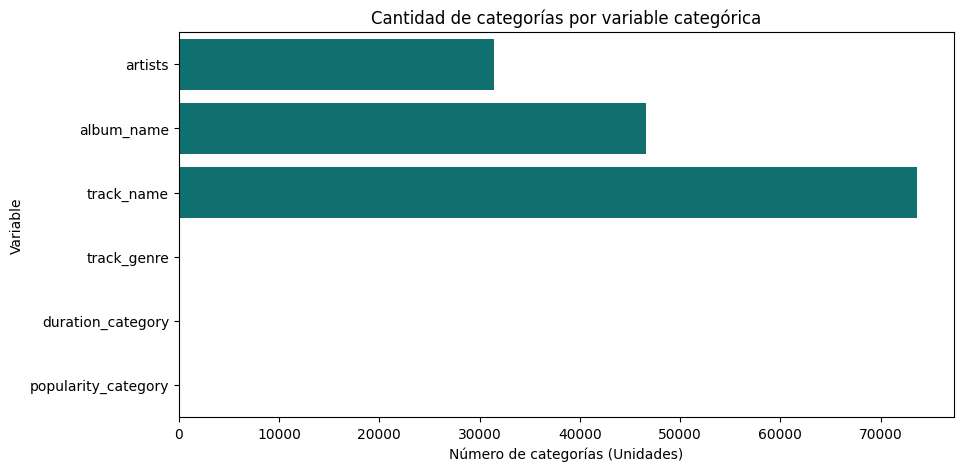

In [120]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cardinalidad,
    x="Cantidad de categorías",
    y="Variable",
    color="teal"
)

plt.title(
    "Cantidad de categorías por variable categórica"
)

plt.xlabel("Número de categorías (Unidades)")
plt.ylabel("Variable")

plt.show()

Esta visualización permite comparar fácilmente la cantidad de categorías existentes en cada variable.

El análisis es especialmente útil para justificar la selección de BinaryEncoder para las variables categóricas con mayor cardinalidad.

---

# Definición del orden de las variables ordinales

In [124]:
# Definición explícita del orden de las variables ordinales.
# Este orden será utilizado por OrdinalEncoder para asignar
# valores numéricos respetando la jerarquía natural de cada categoría.

categories_ordinal = [

    # Duración de la canción: Corta -> Muy larga
    [
        'Corta',
        'Media',
        'Larga',
        'Muy larga'

    ]
]

# Variables categóricas ordinales
# Estas variables poseen un orden natural entre sus categorías,
# por lo que serán codificadas mediante OrdinalEncoder
# utilizando el orden definido en 'categories_ordinal'.

cols_ordinal = [
    'duration_category'
]


# Variables categóricas de alta cardinalidad.
# Se utilizará BinaryEncoder para reducir la cantidad de columnas
# generadas en comparación con OneHotEncoder, manteniendo gran parte
# de la información de las categorías y disminuyendo la dimensionalidad
# del conjunto de datos.

cols_binary = [
    'artists',
    'album_name',
    'track_name',
    'track_genre'
]

cols_numeric = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_min'
]

---

# Construcción del pipeline ordinal

Para la variable ordinal se crea un pipeline independiente:

In [125]:
ordinal_pipeline = Pipeline([
    (
        'ordinal',
        OrdinalEncoder(
            categories=categories_ordinal
        )
    ),
    (
        'scaler',
        StandardScaler()
    )
])

Esta decisión permite mantener el orden ordinal y, al mismo tiempo, aplicar una escala comparable con las variables numéricas.

---

# Construcción del `ColumnTransformer`

El preprocesamiento completo se integra mediante:

In [127]:
pipeline = ColumnTransformer(
    transformers=[
        (
            'bin',
            BinaryEncoder(),
            cols_binary
        ),
        (
            'ord',
            ordinal_pipeline,
            cols_ordinal
        ),
        (
            'num',
            StandardScaler(),
            cols_numeric
        )
    ],
    remainder='drop'
)

El `ColumnTransformer` permite aplicar diferentes transformaciones de manera independiente, dependiendo del tipo de variable.

En este caso, las variables del dataset se distribuyen en tres grupos principales: 
categóricas de alta cardinalidad, ordinales y numéricas. Cada grupo recibe la transformación correspondiente antes de combinarse nuevamente en un único dataset transformado.

---

# Uso de `remainder='drop'` en el pipeline

El parámetro:

`remainder='drop'`

indica que cualquier columna que no haya sido incluida explícitamente en alguno de los grupos definidos será descartada por el `ColumnTransformer`.

Esto permite controlar exactamente qué variables ingresarán al conjunto final de características.

En este proyecto, esta decisión resulta particularmente importante porque:

`popularity`

y:

`popularity_category`

no deben formar parte de las variables predictoras.

---

# Separación entre variables predictoras y objetivo

Se construye el conjunto de variables predictoras `X`:

In [ ]:
X = df.drop(
    columns=[
        'popularity',
        'popularity_category'
    ]
)

# La variable objetivo inicialmente se obtiene mediante:
y = df['popularity_category']

Se eliminan ambas variables porque:

`popularity`: corresponde a la variable original a partir de la cual se construyó el objetivo.

`popularity_category`: corresponde directamente a la variable objetivo.

---

# Transformación de `popularity_category` a valores numéricos

Para representar las categorías de popularidad mediante valores numéricos se define un mapeo explícito:

In [129]:
mapeo_popularidad = {
    'Muy baja': 0,
    'Baja': 1,
    'Media': 2,
    'Alta': 3,
    'Muy alta': 4
}

y = df['popularity_category'].map(mapeo_popularidad)

Esta transformación permite representar la variable objetivo de forma numérica para los modelos de clasificación.

Es importante diferenciar esta transformación del `OrdinalEncoder` utilizado para las variables predictoras.

En este caso, `popularity_category` corresponde al target, por lo que se realiza un mapeo explícito en lugar de incluirla dentro del `ColumnTransformer`.

---

# Separación Train/Test

Los datos se dividen utilizando:

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Se utiliza una proporción de:

80 % → entrenamiento

20 % → prueba

---

# Uso de `random_state=42` en `Train_test_split`

El parámetro:

`random_state=42`

permite obtener una división reproducible.

Esto significa que al ejecutar nuevamente el código bajo las mismas condiciones, se obtiene la misma separación entre entrenamiento y prueba.

Esto facilita:

* Reproducibilidad.
* Comparación de modelos.
* Depuración.
* Documentación del experimento.

---

# Uso de `stratify=y` en `Train_test_split`

para mantener aproximadamente la misma distribución de las cinco categorías de popularidad tanto en entrenamiento como en prueba.

Esto es especialmente importante porque el problema corresponde a una clasificación multiclase con cinco categorías:

0 → Muy baja

1 → Baja

2 → Media

3 → Alta

4 → Muy alta

---

# Ajuste y transformación del pipeline

Una vez realizada la división, se ajusta el pipeline únicamente utilizando el conjunto de entrenamiento:

In [134]:
X_train_transformado = pipeline.fit_transform(X_train)

X_test_transformado = pipeline.transform(X_test)

columnas_transformadas = pipeline.get_feature_names_out()

df_train_preprocesado = pd.DataFrame(
    X_train_transformado,
    columns=columnas_transformadas,
    index=X_train.index
)

df_test_preprocesado = pd.DataFrame(
    X_test_transformado,
    columns=columnas_transformadas,
    index=X_test.index
)

df_train_preprocesado['popularity_category'] = y_train
df_test_preprocesado['popularity_category'] = y_test

El método `fit_transform()` realiza dos operaciones:

* Calcula los parámetros necesarios utilizando `X_train`.

* Aplica las transformaciones a `X_train`.

Por ejemplo, `StandardScaler` calcula la media y desviación estándar utilizando exclusivamente los datos de entrenamiento.

In [137]:
df_train_preprocesado.head()

,bin__artists_0,bin__artists_1,bin__artists_2,bin__artists_3,bin__artists_4,bin__artists_5,bin__artists_6,bin__artists_7,bin__artists_8,bin__artists_9,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
7631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
11659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
40000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
19925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
93716,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


In [138]:
df_test_preprocesado.head()

,bin__artists_0,bin__artists_1,bin__artists_2,bin__artists_3,bin__artists_4,bin__artists_5,bin__artists_6,bin__artists_7,bin__artists_8,bin__artists_9,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
4064,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
67107,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
66713,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
18154,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
25733,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [139]:
# Exportar conjuntos preprocesados
df_train_preprocesado.to_csv(
    "../dataset/Spotify_train_preprocesado.csv",
    index=False
)

df_test_preprocesado.to_csv(
    "../dataset/Spotify_test_preprocesado.csv",
    index=False
)